# Removing Background Version-1

In [13]:
# ! conda create -n inpaint310 python=3.10 -y
# ! conda activate inpaint310

In [14]:
# pip install torch torchvision --extra-index-url https://download.pytorch.org/whl/cpu
# # 如果你是 Apple 芯片且想用 MPS，直接 pip 安装 torch 即可（无需上面 index-url）
# pip install craft-text-detector opencv-python scikit-image pillow numpy
# # 轻量进阶：装 “lama-cleaner” 做 LaMa/ZITS 推理（会自动拉权重）
# # pip install lama-cleaner==0.39.0
# pip install lama-cleaner==0.37.1

In [15]:
# ! conda list opencv

In [16]:
# ! pip install craft-text-detector

In [17]:
# !python -m pip uninstall -y opencv-python scikit-image
# !python -m pip install -U "numpy>=2.0" "opencv-python>=4.10.0.84" "scikit-image>=0.24" "pillow>=10.3"

# !python -m pip install -U ipykernel
# !python -m ipykernel install --user --name inpaint310 --display-name "inpaint310_new"

# !export PIP_USER=0

In [18]:
import platform
print('Python:', platform.python_version())
try:
    import torch
    dev = 'mps' if torch.backends.mps.is_available() else ('cuda' if torch.cuda.is_available() else 'cpu')
    print('Torch:', torch.__version__, '| device:', dev)
except Exception as e:
    print('Torch 未安装或不可用：', e)

for name in ['cv2','numpy','PIL','skimage']:
    try:
        __import__(name if name!='PIL' else 'PIL.Image')
        print(f'{name} ✓')
    except Exception as e:
        print(f'{name} x -> {e}')

Python: 3.10.19
Torch 未安装或不可用： module 'torch.backends' has no attribute 'mps'
cv2 ✓
numpy ✓
PIL ✓
skimage ✓


In [19]:
# # conda activate inpaint310

# # 先卸载，避免残留
# ! python -m pip uninstall -y torchvision torch torchaudio

# # 安装兼容组合（含 model_urls）
# # CPU 通用（macOS/Intel/M1 都能跑；MPS 不需要就用CPU没问题）
# ! python -m pip install --index-url https://download.pytorch.org/whl/cpu \
#   torch==1.11.0 torchvision==0.12.0

# # 可选：再确认其他依赖保持一致
# ! python -m pip install "numpy==1.26.4" "opencv-python==4.9.0.80" "scikit-image==0.22.*" "pillow>=10.0"

# # # 注册 Jupyter 内核（确保 Notebook 用的是这个环境）
# # ! python -m pip install -U ipykernel
# # ! python -m ipykernel install --user --name inpaint310 --display-name "inpaint310"

In [20]:
# 注册 Jupyter 内核（确保 Notebook 用的是这个环境）
! python -m pip install -U ipykernel
! python -m ipykernel install --user --name inpaint310 --display-name "inpaint310"

Installed kernelspec inpaint310 in /Users/suleynan_suir/Library/Jupyter/kernels/inpaint310


In [21]:
import sys, numpy as np, torchvision, cv2
import torchvision.models.vgg as vgg
print(sys.executable)
print('torchvision:', torchvision.__version__)
print('has model_urls?', hasattr(vgg, 'model_urls'))
print('numpy:', np.__version__, 'cv2:', cv2.__version__)

/opt/anaconda3/envs/inpaint310/bin/python3.10
torchvision: 0.12.0
has model_urls? True
numpy: 1.26.4 cv2: 4.9.0


- 以下不运行

In [22]:
# ! pip install lama-cleaner

In [23]:
# ! pip install -U iopaint

In [24]:
# ! pip install -U iopaint opencv-python pillow matplotlib

In [25]:
# input_image = '/Users/suleynan_suir/Desktop/NLP_Package/Project/Hateful-Image-Project/data/img/01258.png'  
# output_image = '/Users/suleynan_suir/Desktop/NLP_Package/Project/Hateful-Image-Project/data_preprocess/baseline/txtRemove_resultPck/01258_mask.png'
# lama_output = '/Users/suleynan_suir/Desktop/NLP_Package/Project/Hateful-Image-Project/data_preprocess/baseline/txtRemove_resultPck/01258output_lama.png'

In [26]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from craft_text_detector import Craft
import cv2, numpy as np, os

def generate_text_mask(image_path: str, mask_path: str, dilate_px: int = 4, min_area: int = 80, use_cuda: bool = False):
    """
    image_path: 输入图片
    mask_path: 输出的二值mask路径（PNG）
    dilate_px: 对检测到的区域膨胀的像素，2~6常见
    min_area: 小于该面积的多边形忽略
    use_cuda: 是否使用CUDA（一般macOS为False）
    """
    craft = Craft(output_dir='craft_out', crop_type='poly', cuda=use_cuda)
    pred = craft.detect_text(image_path)
    polys = pred.get('boxes', [])
    img = cv2.imread(image_path)
    assert img is not None, f'无法读取图像: {image_path}'
    H, W = img.shape[:2]
    mask = np.zeros((H, W), dtype=np.uint8)

    # 栅格化 + 面积过滤
    for poly in polys:
        poly = np.array(poly, dtype=np.int32)
        area = cv2.contourArea(poly)
        if area >= min_area:
            cv2.fillPoly(mask, [poly], 255)

    # 边缘膨胀，减少修复边界露馅
    if dilate_px > 0:
        k = 2 * dilate_px + 1
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (k, k))
        mask = cv2.dilate(mask, kernel)

    os.makedirs(os.path.dirname(mask_path) or '.', exist_ok=True)
    cv2.imwrite(mask_path, mask)
    craft.unload_craftnet_model(); craft.unload_refinenet_model()
    return mask

print('generate_text_mask 函数已定义。')

def inpaint_one_cv(
    image_path: str,
    mask_path: str,
    out_path: str,
    method: str = "telea",     # "telea" 或 "ns"（Navier-Stokes）
    radius: int = 3,           # 修复半径，文本细条建议 2~5
    dilate_px: int = 0,        # 掩码可选膨胀像素，边界更干净可设 1~3
    show: bool = True          # 是否出图（四联图）
) -> str:
    """
    一站式输入输出：读图 -> 掩码对齐/二值化 -> OpenCV inpaint -> 保存 -> 可视化
    完全不使用 Pillow/imageio，避免 PNG 插件报错。
    """

    # ---- 1) 基础检查 ----
    if not os.path.exists(image_path):
        raise FileNotFoundError(f"原图不存在：{image_path}")
    if not os.path.exists(mask_path):
        raise FileNotFoundError(f"掩码不存在：{mask_path}")
    os.makedirs(os.path.dirname(out_path), exist_ok=True)

    # ---- 2) 读图（OpenCV）----
    # 用 IMREAD_UNCHANGED 兼容 RGBA / 浮点 / 16bit 等，再转 BGR3
    src = cv2.imread(image_path, cv2.IMREAD_UNCHANGED)
    if src is None:
        raise RuntimeError(f"无法解码图像：{image_path}")
    if src.ndim == 2:  # 灰度 -> BGR
        bgr = cv2.cvtColor(src, cv2.COLOR_GRAY2BGR)
    elif src.ndim == 3 and src.shape[2] == 4:  # BGRA -> BGR
        bgr = cv2.cvtColor(src, cv2.COLOR_BGRA2BGR)
    elif src.ndim == 3 and src.shape[2] == 3:
        bgr = src
    else:
        raise RuntimeError(f"不支持的图像形状：{src.shape}")
    # 仅用于展示：转 RGB
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

    # ---- 3) 读掩码并标准化 ----
    m = cv2.imread(mask_path, cv2.IMREAD_UNCHANGED)
    if m is None:
        raise RuntimeError(f"无法解码掩码：{mask_path}")
    if m.ndim == 3:  # 彩色/带A通道 -> 灰度
        if m.shape[2] == 4:
            m = cv2.cvtColor(m, cv2.COLOR_BGRA2BGR)
        m = cv2.cvtColor(m, cv2.COLOR_BGR2GRAY)
    # 尺寸对齐
    if (m.shape[0], m.shape[1]) != (rgb.shape[0], rgb.shape[1]):
        m = cv2.resize(m, (rgb.shape[1], rgb.shape[0]), interpolation=cv2.INTER_NEAREST)
    # 二值化：白=需要修复区域
    _, mask_bin = cv2.threshold(m, 127, 255, cv2.THRESH_BINARY)

    # 可选：膨胀掩码，扩大修复范围（处理贴边文字更干净）
    if dilate_px > 0:
        k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2*dilate_px + 1, 2*dilate_px + 1))
        mask_bin = cv2.dilate(mask_bin, k, iterations=1)

    # ---- 4) Inpaint（OpenCV）----
    if mask_bin.sum() == 0:
        # 掩码全黑：直接复制
        print("[提示] 掩码全黑，没有需要修复的区域，直接复制原图到输出。")
        out_bgr = bgr.copy()
    else:
        algo = cv2.INPAINT_TELEA if method.lower() == "telea" else cv2.INPAINT_NS
        out_bgr = cv2.inpaint(bgr, (mask_bin > 0).astype(np.uint8), radius, algo)

    # 保存
    cv2.imwrite(out_path, out_bgr)

    # ---- 5) 可视化（四联图）----
    if show:
        overlay = rgb.copy()
        red = np.zeros_like(overlay); red[..., 0] = 255  # 红色
        alpha = (mask_bin > 0).astype(np.float32) * 0.45
        overlay = (overlay * (1 - alpha[..., None]) + red * (alpha[..., None])).astype(np.uint8)

        out_rgb = cv2.cvtColor(out_bgr, cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(16, 9))
        panels = [
            (cv2.cvtColor(mask_bin, cv2.COLOR_GRAY2RGB), "Mask (w-target RoI)"),
            (overlay, "Raw + Msk"),
            (rgb, "Raw"),
            (out_rgb, f"Output: (OpenCV inpaint-{method}, r-{radius})"),
        ]
        for i, (im, title) in enumerate(panels, 1):
            ax = plt.subplot(1, 4, i)
            ax.imshow(im)
            ax.set_title(title, fontsize=12, weight="bold")
            ax.axis("off")
        plt.tight_layout()
        plt.show()

    return out_path

generate_text_mask 函数已定义。


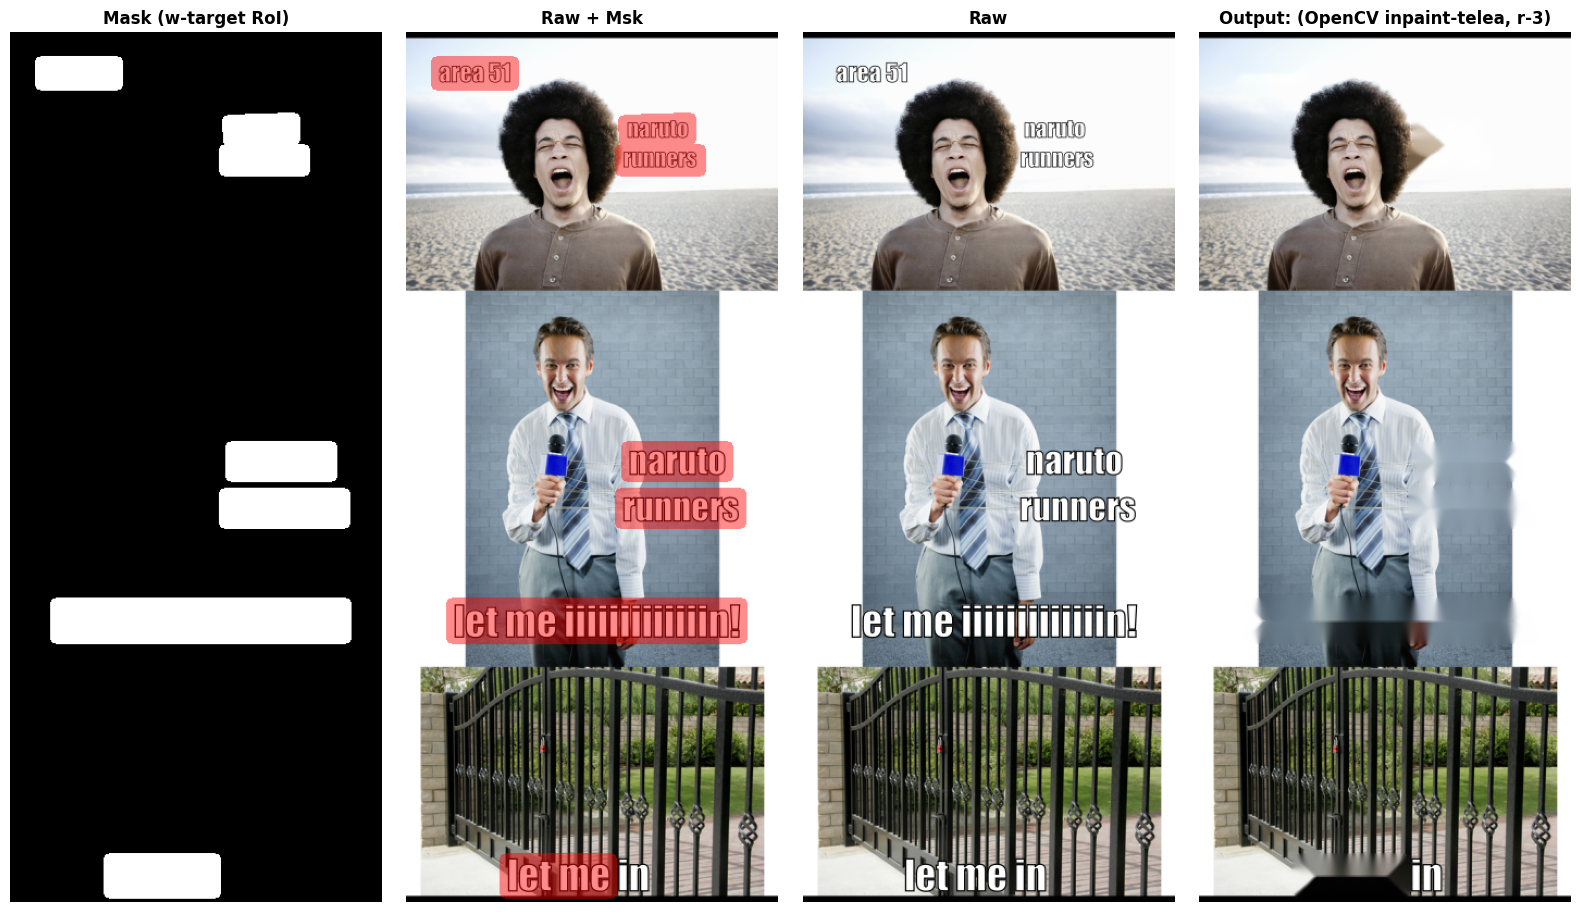

'/Users/suleynan_suir/Desktop/NLP_Package/Project/Hateful-Image-Project/data_preprocess/baseline/txtRemove_resultPck/01359_output_opencv.png'

In [27]:
# input_image = '/Users/suleynan_suir/Desktop/NLP_Package/Project/Hateful-Image-Project/data/img/01359.png'           # <- 改成你的图片

# mask_path = '/Users/suleynan_suir/Desktop/NLP_Package/Project/Hateful-Image-Project/data_preprocess/baseline/txtRemove_resultPck/01359_mask.png'

# # 生成mask（常用：dilate_px=4，min_area=80~200）
# generate_text_mask(input_image, output_mask, dilate_px=4, min_area=120, use_cuda=False)

# ##################################################################################################################

# lama_output = "/Users/suleynan_suir/Desktop/NLP_Package/Project/Hateful-Image-Project/data_preprocess/baseline/txtRemove_resultPck/01359_output_opencv.png"

# inpaint_one_cv(
#     image_path=input_image,
#     mask_path=mask_path,
#     out_path=lama_output,
#     method="telea",    # 或 "ns"
#     radius=3,          # 可调：2~5
#     dilate_px=1,       # 掩码边缘稍微膨胀 1 像素，清理更干净
#     show=True
# )

Generating mask for 03246.png...
Inpainting 03246.png...


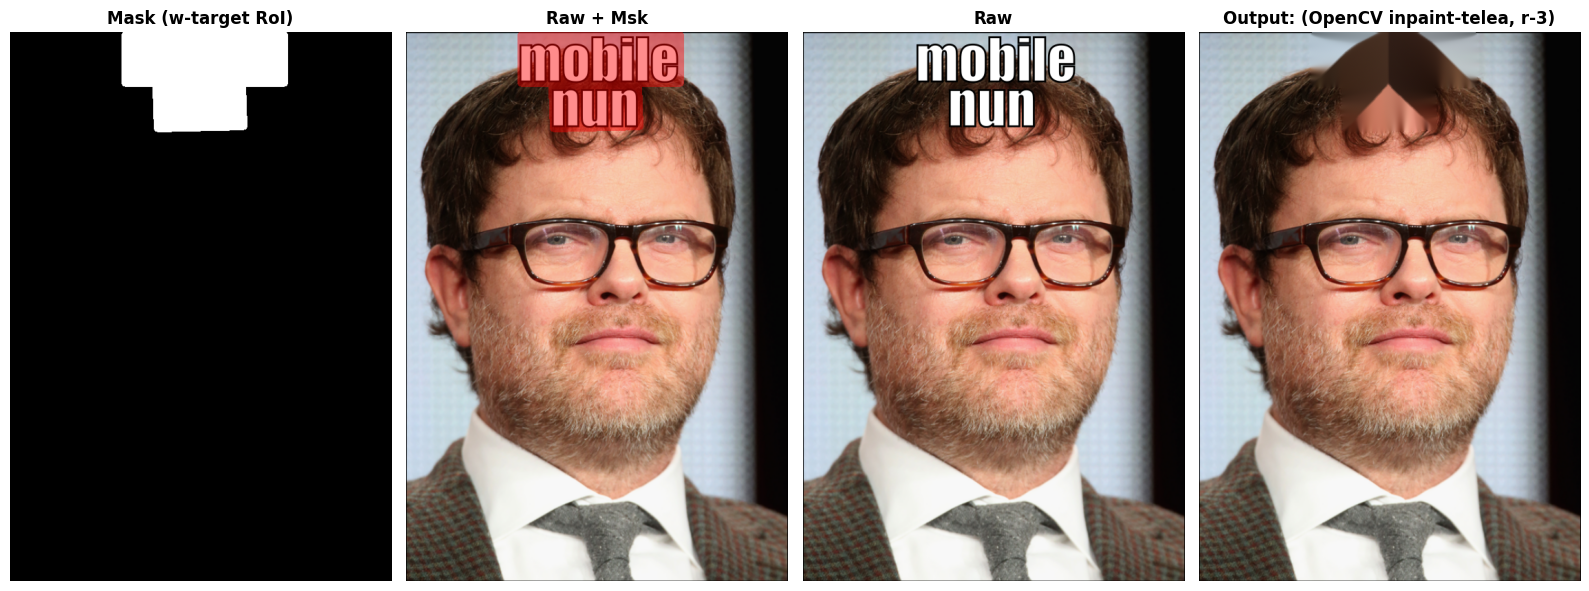

Generating mask for 71360.png...
Inpainting 71360.png...


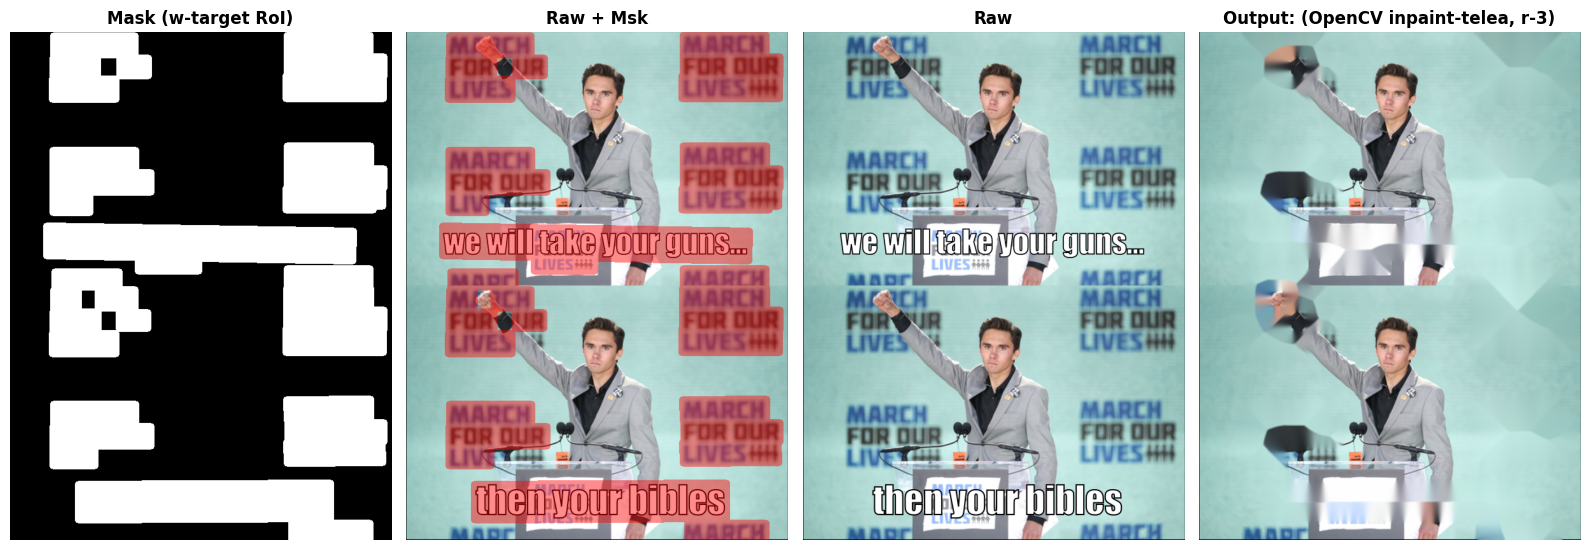

Generating mask for 58609.png...
Inpainting 58609.png...


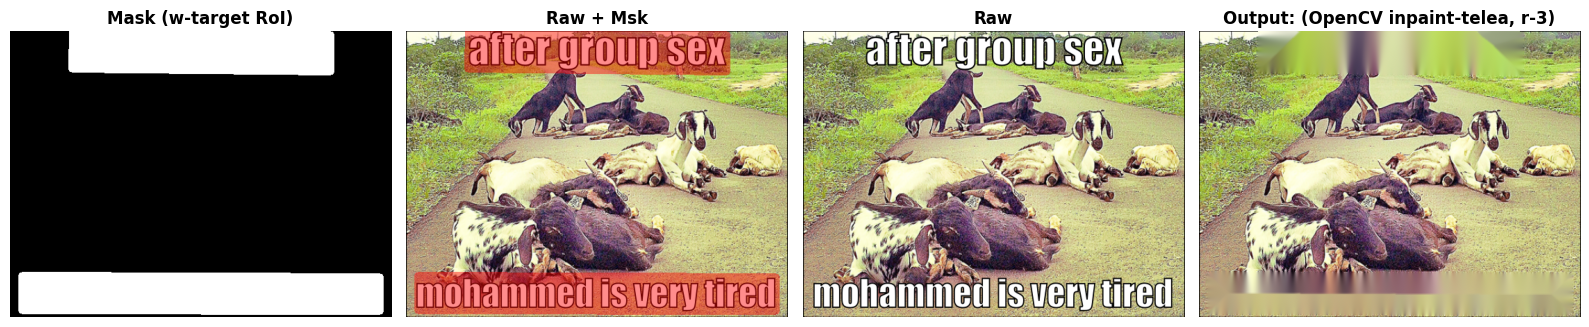

Generating mask for 75693.png...
Inpainting 75693.png...


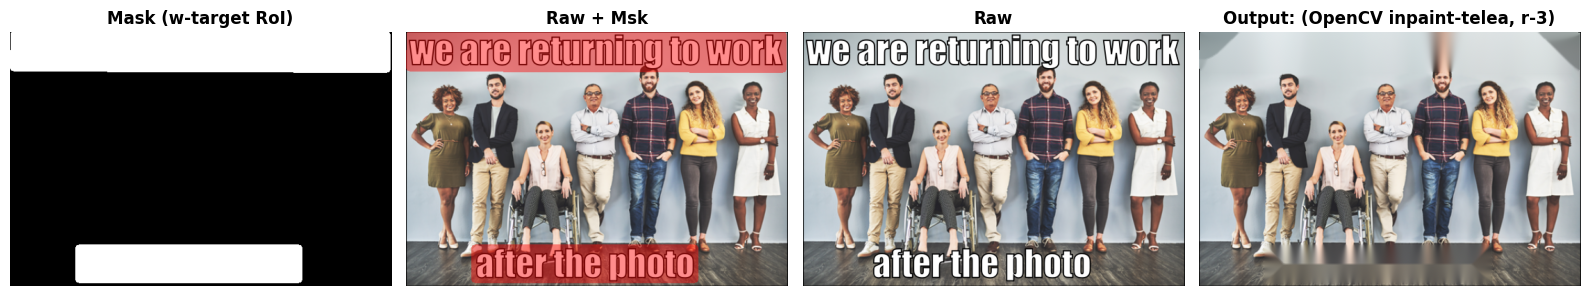

Generating mask for 26085.png...
Inpainting 26085.png...


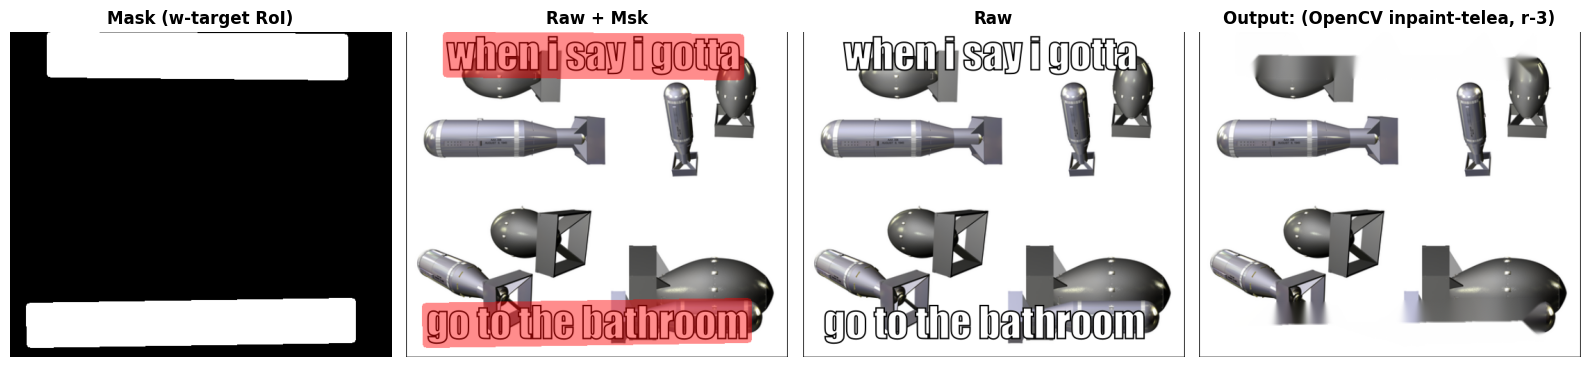

Processing completed for all selected images.


In [30]:
import os
import random
from PIL import Image

# Directory containing the images
image_dir = '/Users/suleynan_suir/Desktop/NLP_Package/Project/Hateful-Image-Project/data/img/'

# Directory to save the generated masks and outputs
output_dir = '/Users/suleynan_suir/Desktop/NLP_Package/Project/Hateful-Image-Project/data_preprocess/baseline/txtRemove_resultPck/'

# Define the number of images you want to randomly select
n = 5  # For example, select 5 random images

# List all image files in the directory
image_files = [f for f in os.listdir(image_dir) if f.endswith(('.png', '.jpg', '.jpeg'))]

# Randomly select `n` images
selected_images = random.sample(image_files, n)

# Process each selected image
for image_file in selected_images:
    input_image = os.path.join(image_dir, image_file)
    
    # Generate the mask file path
    mask_path = os.path.join(output_dir, f'{image_file.split(".")[0]}_mask.png')
    
    # Generate the output file path for inpainting
    lama_output = os.path.join(output_dir, f'{image_file.split(".")[0]}_output_opencv.png')
    
    # Generate the mask
    print(f"Generating mask for {image_file}...")
    generate_text_mask(input_image, mask_path, dilate_px=4, min_area=120, use_cuda=False)

    # Inpainting
    print(f"Inpainting {image_file}...")
    inpaint_one_cv(
        image_path=input_image,
        mask_path=mask_path,
        out_path=lama_output,
        method="telea",    # Or "ns"
        radius=3,          # Adjustable: 2~5
        dilate_px=1,       # Slightly dilate mask edges by 1 pixel
        show=True
    )

print("Processing completed for all selected images.")


---

In [32]:
!conda list --explicit > removeTxt_environmentV1.txt